In [1]:
import matplotlib.pyplot as plt
import torchvision
import torchvision.transforms as transforms
from collections import Counter
import numpy as np
from torchvision.datasets import CIFAR10
import torch
from torch.utils.data import DataLoader, random_split
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

In [3]:
transform = transforms.ToTensor()
train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

100%|██████████| 170M/170M [00:10<00:00, 16.2MB/s]


In [4]:
class_names = train_dataset.classes
print(class_names)
print(len(class_names))

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
10


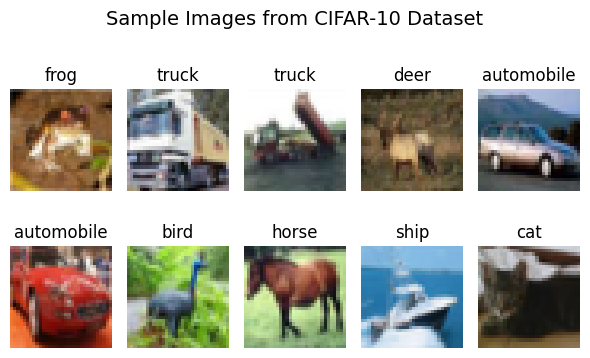

In [5]:
fig, axes = plt.subplots(2, 5, figsize=(6, 4))
for i in range(10):
    image, label = train_dataset[i]
    ax = axes[i//5, i%5]
    ax.imshow(image.permute(1, 2, 0))  # convert CHW to HWC
    ax.set_title(class_names[label])
    ax.axis('off')
plt.suptitle("Sample Images from CIFAR-10 Dataset", fontsize=14)
plt.tight_layout()
plt.show()

# Class Distribution

{'frog': 5000, 'truck': 5000, 'deer': 5000, 'automobile': 5000, 'bird': 5000, 'horse': 5000, 'ship': 5000, 'cat': 5000, 'dog': 5000, 'airplane': 5000}


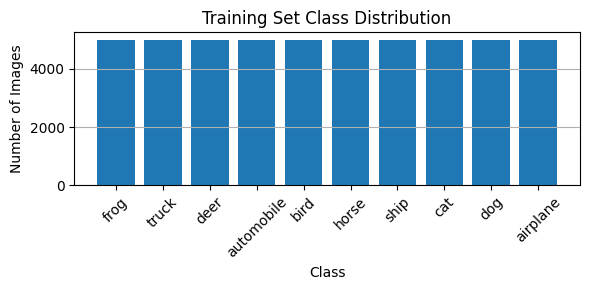

In [6]:
labels = [label for _, label in train_dataset]

# Count occurrences of each class
class_counts = Counter(labels)

# Convert to class name keys
class_counts_named = {class_names[k]: v for k, v in class_counts.items()}
print(class_counts_named)

# Plot
plt.figure(figsize=(6, 3))
plt.bar(class_counts_named.keys(), class_counts_named.values())
plt.title("Training Set Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()


In [7]:
CT_labels = []
for _, label in train_dataset:
    CT_labels.append(label)


CT_class_counts = Counter(CT_labels)

CT_class_counts_named = {}
for idx, count in CT_class_counts.items():
    CT_class_counts_named[train_dataset.classes[idx]] = count

# Step 4: Print counts
print("CT_Class Counts:")
for name, count in CT_class_counts_named.items():
    print(f"{name}: {count}")

CT_Class Counts:
frog: 5000
truck: 5000
deer: 5000
automobile: 5000
bird: 5000
horse: 5000
ship: 5000
cat: 5000
dog: 5000
airplane: 5000


# Normalization

## MinMaxScaler

When normalizing 8-bit image pixels to the $[0, 1]$ interval, the min-max formula uses $x_{\min} = 0$ and $x_{\max} = 255$:

$$x_{\text{scaled}} = \frac{x - 0}{255 - 0} = \frac{x}{255}$$

Because $255$ is the maximum possible value:
1. A pixel value of $255$ (pure white) evaluates to $\frac{255}{255} = 1.0$.

2. A pixel value close to $255$—such as $250$—evaluates to $\frac{250}{255} \approx 0.980$.

3. A pixel value of $0$ (pure black) evaluates to $\frac{0}{255} = 0.0$.A neutral gray value of $128$ evaluates to $\frac{128}{255} \approx 0.502$.

In [8]:
CT_image, CT_label = train_dataset[0]

# Step 2: Print properties
print("CT_Image shape:", CT_image.shape)
print("CT_Min pixel value:", float(CT_image.min()))
print("CT_Max pixel value:", float(CT_image.max()))
print("CT_Label index:", CT_label)
print("CT_Label name:", train_dataset.classes[CT_label])

CT_Image shape: torch.Size([3, 32, 32])
CT_Min pixel value: 0.0
CT_Max pixel value: 1.0
CT_Label index: 6
CT_Label name: frog


# **Flattening Images**

Our CIFAR-10 images are in shape **[3, 32, 32]**, meaning 3 color channels (RGB), each with a 32×32 grid of pixel values. However, basic neural networks (like the MLP we’ll build soon) accept **1D input vectors** — not 2D/3D structures.

Out Goal here is to convert each image from shape: [C, H, W] = [3, 32, 32] to a flat vector of shape: [3072] = 3 × 32 × 32

This process is known as **flattening** or **vectorization**.

**Visual Example**

Let’s visualize what flattening does to a small image:

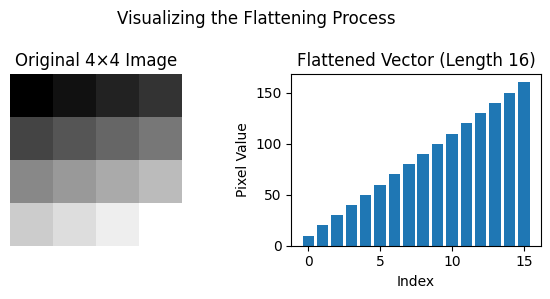

In [9]:
# Simulate a grayscale 4x4 image (1 channel)
image = np.array([
    [10, 20, 30, 40],
    [50, 60, 70, 80],
    [90, 100, 110, 120],
    [130, 140, 150, 160]
])

# Flatten it
flattened = image.flatten()

# Plot original and flattened
fig, axs = plt.subplots(1, 2, figsize=(6, 3))

axs[0].imshow(image, cmap='gray')
axs[0].set_title("Original 4×4 Image")
axs[0].axis('off')

axs[1].bar(np.arange(len(flattened)), flattened)
axs[1].set_title("Flattened Vector (Length 16)")
axs[1].set_xlabel("Index")
axs[1].set_ylabel("Pixel Value")

plt.suptitle("Visualizing the Flattening Process")
plt.tight_layout()
plt.show()

# MLPs Need 1D Vectors as input this demands flattening which leads to loss of spatial locality

In [11]:

image, label = train_dataset[0]
print(f"Original shape: {image.shape}")

# Flatten the image
flattened = image.view(-1)
print(f"Flattened shape: {flattened.shape}")

Original shape: torch.Size([3, 32, 32])
Flattened shape: torch.Size([3072])


In [12]:
transform = transforms.Compose([
    transforms.ToTensor(),                            # [3, 32, 32], scaled to [0,1]
    transforms.Lambda(lambda x: x.view(-1))           # Flatten to [3072]
])

In [13]:
# Reload with new transform
train_dataset = CIFAR10(root='./data', train=True, transform=transform, download=True)
test_dataset = CIFAR10(root='./data', train=False, transform=transform, download=True)

In [14]:
# Verify flattening

CT_image_already_flat, CT_label_flat = train_dataset[0]
CT_image_flat = CT_image_already_flat.view(3, 32, 32)

CT_flattened = CT_image_flat.view(-1)

print("CT_Original shape:", CT_image_flat.shape)
print("CT_Flattened shape:", CT_flattened.shape)

CT_Original shape: torch.Size([3, 32, 32])
CT_Flattened shape: torch.Size([3072])


# **DataLoaders — Train, Validation, and Test**

Now that our **CIFAR-10** dataset is loaded and normalized, we’ll use **PyTorch DataLoaders** to prepare it for training.

>`torch.utils.data.DataLoader` helps with efficient and flexible data loading by:

- **Batching**: Feeds small groups of images (e.g., 64) at each training step
- **Shuffling**: Randomizes the order of samples each epoch to improve generalization
- **Parallel Loading**: Uses multiple workers to load data faster in the background

CIFAR-10 provides us with: **50,000 training images** and **10,000 test images**


> Split?

- **Training set (45K)**: Used to train the model (weights updated here)
- **Validation set (5K)**: Used during training to monitor performance and detect overfitting
- **Test set (10K)**: Held out until the end for final unbiased evaluation

> Using separate validation and test sets allows us to monitor model behavior during training without contaminating our final performance estimate.

In [15]:
batch_size = 64

train_size = int(0.9 * len(train_dataset))  # 45,000
val_size = len(train_dataset) - train_size  # 5,000

train_data, val_data = random_split(train_dataset, [train_size, val_size])


train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


print(f" Train batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")


 Train batches: 704
Validation batches: 79
Test batches: 157


In [16]:
for images, labels in train_loader:
    print(f" Batch shape: {images.shape}")
    print(f"Labels shape: {labels.shape}")
    break

 Batch shape: torch.Size([64, 3072])
Labels shape: torch.Size([64])


# MLP For CIFAR-10

- **Input layer**: 3072 units (32×32×3)
- **Hidden layer**: 128 units + ReLU
- **Output layer**: 10 units (logits, one per class)

In [17]:
class SimpleMLP(nn.Module):
    def __init__(self, input_dim=3072, hidden_dim=128, output_dim=10):
        super(SimpleMLP, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x):
        return self.net(x)

# Instantiate the model
mlp_model = SimpleMLP()

# Print model summary
print(mlp_model)


SimpleMLP(
  (net): Sequential(
    (0): Linear(in_features=3072, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
mlp_model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(mlp_model.parameters(), lr=0.001)

# Tracking
num_epochs = 10
train_losses = []
train_accuracies = []

for epoch in range(num_epochs):
    mlp_model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        # Forward pass
        outputs = mlp_model(images)
        loss = criterion(outputs, labels)

        # Backpropagation and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Accumulate stats
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    # Epoch summary
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] - Loss: {epoch_loss:.4f} | Accuracy: {epoch_acc:.4f}")

Epoch [1/10] - Loss: 1.8920 | Accuracy: 0.3202
Epoch [2/10] - Loss: 1.7277 | Accuracy: 0.3827
Epoch [3/10] - Loss: 1.6497 | Accuracy: 0.4157
Epoch [4/10] - Loss: 1.6071 | Accuracy: 0.4296
Epoch [5/10] - Loss: 1.5837 | Accuracy: 0.4390
Epoch [6/10] - Loss: 1.5619 | Accuracy: 0.4445
Epoch [7/10] - Loss: 1.5406 | Accuracy: 0.4536
Epoch [8/10] - Loss: 1.5271 | Accuracy: 0.4569
Epoch [9/10] - Loss: 1.5150 | Accuracy: 0.4609
Epoch [10/10] - Loss: 1.5059 | Accuracy: 0.4638


The model is **learning steadily** — loss is decreasing and accuracy is improving. But performance is still **far from ideal**. With **only one hidden layer** and **no spatial awareness**, it’s expected that:

  - The MLP **struggles to capture image structure** (e.g., edges, shapes, textures)
  - It **treats pixels as independent features**, which is suboptimal for images
  - The model is **underfitting**, though improving

> What Can Help?

- **Deeper MLPs** (more hidden layers)
- **Better optimizers or learning rate tuning**
- **Convolutional Neural Networks (CNNs)** — designed to leverage **spatial locality**


# Evaluation On The Test Set

✅ Test Accuracy: 0.4471


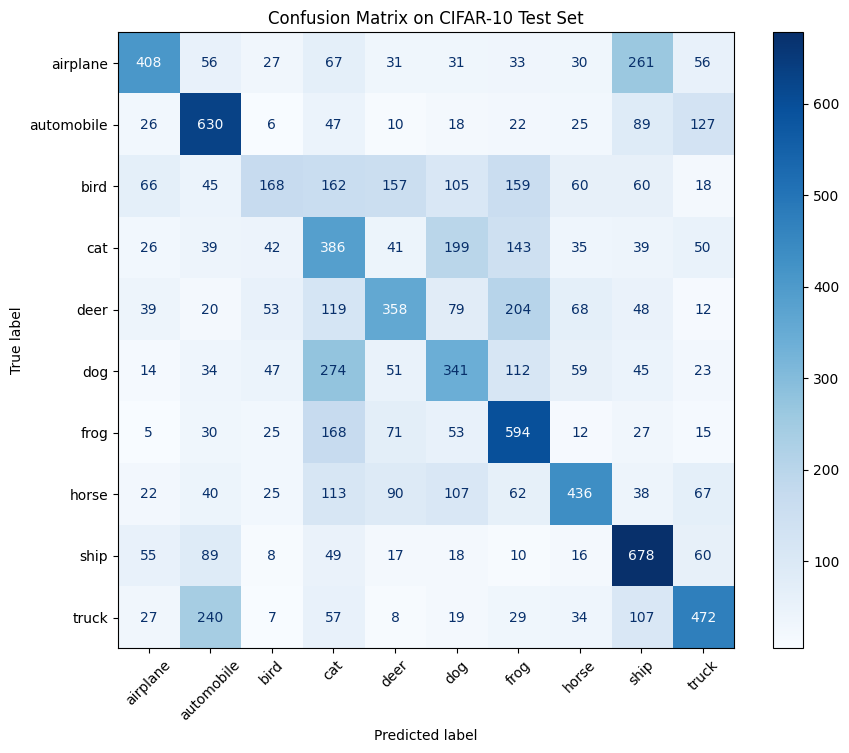

In [19]:
mlp_model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = mlp_model(images)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())


test_acc = accuracy_score(all_labels, all_preds)
print(f"✅ Test Accuracy: {test_acc:.4f}")

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix on CIFAR-10 Test Set")
plt.show()
